# Assignment 06 — ST: forecasting tomorrow's trading range (NYSE, 2010–2016)

**Author:** Lưu Anh Dũng (B23DCDK036) | **Course:** Intelligent System Development | **Lecturer:** Assoc. Prof. Dinh Que Tran, Ph.D.

**Dataset:** *New York Stock Exchange* (Kaggle `dgawlik/nyse`), file `prices-split-adjusted.csv`: daily open, high, low, close and volume of 501 S&P 500 companies, 2010-01-04 → 2016-12-30, 851k rows, prices adjusted for splits.

**Why the range and not the return.** Tomorrow's *return* of a liquid stock is close to unpredictable (efficient markets: the best forecast is ≈ 0). Tomorrow's *risk* is not: large moves cluster ("volatility clustering", calm weeks follow calm weeks). The daily range is a classic risk measure (Parkinson, 1980):

$$\text{range}_t=\ln\frac{\text{high}_t}{\text{low}_t},\qquad \text{e.g. high }102,\ \text{low }100\ \Rightarrow\ \ln 1.02=0.0198\ (\approx 2\,\%).$$

**Task.** For each of the 250 most-traded stocks, read the last **T = 30 trading days** (7 features) and predict **log range of the next day** (many-to-one regression, one model for all stocks). Directional accuracy asks the trader's question: *will tomorrow be calmer or wilder than today?*
**Runs:** `ST-SC-RNN` (NumPy), `ST-TF-RNN` (Keras), `ST-PT-RNN` (PyTorch) from identical weights; LSTM and GRU in Keras and PyTorch. Theory: [00_rnn_concepts.ipynb](00_rnn_concepts.ipynb).

## 1. Setup

Same seed, same hyper-parameters and the same shared code for training, evaluation and plotting as the EC notebook; only data, window length (30 days instead of 10 orders) and metrics differ. `A6_SMOKE=1` runs 25 stocks for 2 epochs.

In [1]:
import os, time, json, random, warnings
from pathlib import Path
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.nn.functional as Fn
from IPython.display import display
warnings.filterwarnings("ignore"); tf.get_logger().setLevel("ERROR")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 150, "savefig.bbox": "tight"})

SEED = 42
SMOKE = os.environ.get("A6_SMOKE") == "1"          # quick test: small data, 2 epochs, outputs go to */smoke/
tf.config.set_visible_devices([], "GPU")         # tensorflow-metal would put Keras on the Mac GPU; keep all three on CPU
random.seed(SEED); np.random.seed(SEED); keras.utils.set_random_seed(SEED); torch.manual_seed(SEED)

CODE = "ST"
DATA = Path("../dataset/st")
RES = Path("results") / ("smoke" if SMOKE else "")
IMG = Path("../report/images") / ("smoke" if SMOKE else "")
RES.mkdir(parents=True, exist_ok=True); IMG.mkdir(parents=True, exist_ok=True)

H = 32            # hidden size: dimension of the state h_t
BATCH = 128       # windows per parameter update
LR = 1e-3         # Adam learning rate (constant)
EPS = 1e-7        # Adam epsilon (Keras default; set in PyTorch and scratch too)
CLIP = 1.0        # gradient clipping: global norm of all gradients
PATIENCE = 5      # early stopping patience (epochs) on the validation loss
MAX_EPOCHS = 2 if SMOKE else 30
T = 30            # window length (time steps read before each prediction)

# a 32-unit RNN on batches of 128 is too small to profit from a GPU; CPU keeps the three implementations comparable
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("TensorFlow", tf.__version__, "| Keras", keras.__version__, "| PyTorch", torch.__version__, "| PT device:", dev, "| smoke:", SMOKE)

TensorFlow 2.18.1 | Keras 3.15.1 | PyTorch 2.14.1 | PT device: cpu | smoke: False


### Hyperparameters


| Name | Value | Meaning |
|---|---|---|
| Hidden size H | 32 | dimension of $h_t$ |
| Recurrent layers | 1 | one cell applied over the T steps, many-to-one |
| Activation | tanh | inside the cell; the output unit is linear |
| Loss | MSE | on the z-scored target |
| Optimizer | Adam | $\beta_1=0.9,\ \beta_2=0.999,\ \epsilon=10^{-7}$, lr $10^{-3}$ constant |
| Batch size | 128 | windows per update, reshuffled every epoch |
| Epochs | ≤ 30 | early stopping, patience 5, best weights restored |
| Gradient clipping | 1.0 | global norm of all gradients |
| Initial $W_{xh}$ / $W_{hh}$ / $W_{hy}$ | Glorot uniform / orthogonal / Glorot uniform | biases 0 |
| Seed, precision | 42, float32 | gradient check in float64 |

For this data: $F=7$, so the vanilla RNN has $7\cdot32+32\cdot32+32+32+1=1{,}313$ parameters. A month (≈ 22 trading days) is the horizon used by the classic HAR model of volatility; 30 days covers it with a margin.

## 2. Data

Steps: keep the 467 tickers with the full 1,762-day history → rank by mean dollar volume (close × volume) → keep the top 250 (they share one calendar) → compute 7 features per day → split the **calendar** 70/15/15 → z-score with train-period statistics.

| Feature (per stock and day) | Formula | Small example |
|---|---|---|
| `log_range` (**target at t+1**) | $\ln(\text{range})$ with range $=\ln(\text{high}/\text{low})$, floored at 0.1 % | range 2 % → $\ln 0.02=-3.91$; 4 % → $-3.22$: doubling risk = +0.69, whatever the stock |
| `ret` | $\ln(\text{close}_t/\text{close}_{t-1})$ | 100 → 103: $+0.0296$ |
| `abs_ret` | $\lvert\text{ret}\rvert$ | a −3 % day and a +3 % day carry the same risk information |
| `oc_ret` | $\ln(\text{close}/\text{open})$ | intraday drift |
| `vol_rel` | $\ln(1+\text{volume})$ minus the stock's train-period mean | 0 = normal activity, +0.69 = twice the usual volume |
| `dow_sin/cos` | trading weekday 0–4 on a circle | Monday after a weekend gap |

The log of the range makes the target roughly Gaussian and turns "AAPL 1.2 % vs a small cap 3 %" into a shift, so one model can serve all 250 stocks.

**Split.** Chronological by the *target day*: train until 2014-11-24, validation to 2015-12-11, test = last 15 % of days (2015-12-14 → 2016-12-30, incl. the early-2016 sell-off and the Brexit-vote spike). Windows near a boundary look back into the previous period, targets never do.

**Metrics.** RMSE / MAE of the range in **percentage points** (after undoing log and z-score), RMSE on the z-scale, $R^2_{oos}$ vs the train mean, and **directional accuracy** = share of days on which $\operatorname{sign}(\hat y_{t+1}-y_t)=\operatorname{sign}(y_{t+1}-y_t)$.
**Baselines.** *Persistence* (tomorrow = today), *5-day mean*, *22-day mean*, train mean, and the classic **HAR model** (Corsi, 2009): least squares on today, 5-day mean and 22-day mean, $\hat y_{t+1}=\beta_0+\beta_d y_t+\beta_w\bar y^{(5)}_t+\beta_m\bar y^{(22)}_t$, fitted on train. HAR is the bar a neural network has to clear in volatility forecasting.

In [2]:
N_SERIES = 25 if SMOKE else 250
raw = pd.read_csv(DATA / "prices-split-adjusted.csv", parse_dates=["date"])
cnt = raw.groupby("symbol").size(); complete = cnt[cnt == cnt.max()].index
raw = raw[raw.symbol.isin(complete)]
top = (raw.close * raw.volume).groupby(raw.symbol).mean().nlargest(N_SERIES).index
raw = raw[raw.symbol.isin(top)]
wide = lambda c: raw.pivot(index="symbol", columns="date", values=c).loc[top].to_numpy(np.float64)
Op, Cl, Lo, Hi, Vo = (wide(c) for c in ("open", "close", "low", "high", "volume"))
dates = pd.DatetimeIndex(sorted(raw.date.unique()))
print(f"{len(complete)} tickers with the full {cnt.max()} days; kept {len(top)}: {list(top[:8])} ...")

days = dates[1:]; D = len(days); nS = len(top)                          # first day has no return
rng_ = np.log(np.maximum(Hi / Lo, 1.001))[:, 1:]                         # log(high/low), floored at 0.1 %
ret = np.log(Cl[:, 1:] / Cl[:, :-1]); oc = np.log(Cl / Op)[:, 1:]; lv = np.log1p(Vo)[:, 1:]
c1, c2 = int(0.70 * D), int(0.85 * D)
FEATS = ["log_range", "ret", "abs_ret", "oc_ret", "vol_rel", "dow_sin", "dow_cos"]
S = np.zeros((nS, D, len(FEATS)), np.float32)
S[..., 0] = np.log(rng_); S[..., 1] = ret; S[..., 2] = np.abs(ret); S[..., 3] = oc
S[..., 4] = lv - lv[:, :c1].mean(1, keepdims=True)                        # per-stock volume level from train only
S[..., 5] = np.sin(2 * np.pi * days.dayofweek.to_numpy() / 5)[None]; S[..., 6] = np.cos(2 * np.pi * days.dayofweek.to_numpy() / 5)[None]
mu = S[:, :c1, :5].reshape(-1, 5).mean(0); sd = S[:, :c1, :5].reshape(-1, 5).std(0)
S[..., :5] = (S[..., :5] - mu) / sd
mu_t, sd_t = float(mu[0]), float(sd[0])

def make_windows(lo, hi):
    """Windows whose target day t+1 lies in [lo, hi); the look-back may reach into the previous period."""
    ends = np.arange(max(lo - 1, T - 1), hi - 1)
    X = np.concatenate([S[:, t - T + 1:t + 1] for t in ends]); y = np.concatenate([S[:, t + 1, 0] for t in ends])
    return X, y, np.repeat(ends + 1, nS), np.tile(np.arange(nS), len(ends))
Xtr, ytr, tr_day, tr_ser = make_windows(0, c1)
Xva, yva, va_day, va_ser = make_windows(c1, c2)
Xte, yte, te_day, te_ser = make_windows(c2, D)
if not SMOKE: np.savez(DATA / "splits.npz", days=days.values.astype("datetime64[D]"), series=np.array(top), c1=c1, c2=c2, T=T, mu=mu, sd=sd)
print(f"windows: train {len(Xtr):,} | validation {len(Xva):,} | test {len(Xte):,} | total {len(Xtr)+len(Xva)+len(Xte):,}")
print(f"X shape (N, T, F) = {Xtr.shape} | train < {days[c1].date()} <= validation < {days[c2].date()} <= test <= {days[-1].date()}")
print(f"median daily range: {np.exp(mu_t)*100:.2f} %")

467 tickers with the full 1762 days; kept 250: ['AAPL', 'BAC', 'GOOGL', 'MSFT', 'GOOG', 'AMZN', 'C', 'XOM'] ...
windows: train 300,500 | validation 66,000 | test 66,250 | total 432,750
X shape (N, T, F) = (300500, 30, 7) | train < 2014-11-25 <= validation < 2015-12-14 <= test <= 2016-12-30
median daily range: 1.88 %


**Shape trace.** `S` is a cube (stocks, days, features) = $(250, 1761, 7)$. A window cuts 30 consecutive days of one stock: `X[i]` $(30,7)$; the label is the z-scored log range on day 31. 250 stocks × 1,731 possible target days ≈ 433k windows.

In [3]:
to_pct = lambda z: 100 * np.exp(np.asarray(z) * sd_t + mu_t)            # z-scored log range -> range in %
ybar = float(ytr.mean())
KEY_METRIC = "rmse_pct"
def metrics_fn(z_true, z_pred):
    last = Xte[:, -1, 0] if z_true is yte else Xva[:, -1, 0]               # today's value, for the direction of change
    pt, pp = to_pct(z_true), to_pct(z_pred)
    dt, dp = np.sign(z_true - last), np.sign(z_pred - last); m = (dt != 0) & (dp != 0)
    return dict(rmse_pct=float(np.sqrt(np.mean((pt - pp) ** 2))), mae_pct=float(np.mean(np.abs(pt - pp))),
                rmse=float(np.sqrt(np.mean((z_true - z_pred) ** 2))),
                r2_oos=float(1 - np.sum((z_true - z_pred) ** 2) / np.sum((z_true - ybar) ** 2)),
                dir_acc=float(np.mean(dt[m] == dp[m])) if m.any() else float("nan"))

def har(X): return np.c_[np.ones(len(X)), X[:, -1, 0], X[:, -5:, 0].mean(1), X[:, -22:, 0].mean(1)]
beta = np.linalg.lstsq(har(Xtr).astype(np.float64), ytr.astype(np.float64), rcond=None)[0]
print("HAR coefficients [const, day, week, month]:", beta.round(3))
BASELINES = {"persistence (today)": Xte[:, -1, 0], "5-day mean": Xte[:, -5:, 0].mean(1), "22-day mean": Xte[:, -22:, 0].mean(1),
             "train mean": np.full(len(yte), ybar, np.float32), "HAR linear (day+week+month)": (har(Xte) @ beta).astype(np.float32)}
display(pd.DataFrame({k: metrics_fn(yte, v) for k, v in BASELINES.items()}).T.round(4))

SHOW = list(top).index("AAPL") if "AAPL" in list(top) else 0
def overlay_slice(pred, n=120):
    ix = np.where(te_ser == SHOW)[0][-n:]
    return days[te_day[ix]], to_pct(yte[ix]), to_pct(pred[ix]), "", f"daily range (%), {top[SHOW]}"

HAR coefficients [const, day, week, month]: [-0.005  0.178  0.302  0.443]


,rmse_pct,mae_pct,rmse,r2_oos,dir_acc
persistence (today),1.3852,0.8639,0.9193,0.2759,NaN
5-day mean,1.1631,0.7172,0.7861,0.4705,0.6833
22-day mean,1.1888,0.7265,0.7948,0.4587,0.6943
train mean,1.6528,0.9865,1.0804,0.0000,0.6424
HAR linear (day+week+month),1.1449,0.6820,0.7485,0.5200,0.7004


`dir_acc` excludes days on which either change is exactly 0; *persistence* predicts "no change" and therefore has no direction. A coin flip gives 50 %; because the range mean-reverts (a wild day is usually followed by a calmer one), even the 22-day mean gets a high directional accuracy — the baselines set the real bar.

### Shared evaluation helpers

`finalize` predicts validation and test, writes `results/<run_id>.json`, draws the loss curve and the forecast for one stock, and prints a summary line.

In [4]:
RUNS = {}   # run_id -> result record (+ test predictions)

def median_epoch_time(times):
    times = list(times)
    return float(np.median(times[1:] if len(times) > 1 else times))   # epoch 1 includes one-time set-up

def infer_ms_per_1k(predict_fn, X, reps=3):
    n = min(len(X), 10000); ts = []
    for _ in range(reps):
        t0 = time.perf_counter(); predict_fn(X[:n]); ts.append(time.perf_counter() - t0)
    return float(np.median(ts)) / n * 1e6

def plot_loss(run_id, hist):
    best = int(np.argmin(hist["val_loss"]))
    fig, ax = plt.subplots(figsize=(5.5, 3.4))
    ax.plot(range(1, len(hist["loss"]) + 1), hist["loss"], label="train")
    ax.plot(range(1, len(hist["val_loss"]) + 1), hist["val_loss"], label="validation")
    ax.axvline(best + 1, ls=":", c="grey"); ax.set(xlabel="epoch", ylabel="MSE (z-scored target)", title=f"{run_id}: loss"); ax.legend()
    fig.savefig(IMG / f"{run_id}_loss.png"); plt.show()

def plot_forecast(run_id, pred):
    xs, actual, predicted, xlabel, ylabel = overlay_slice(pred)
    fig, (a, b) = plt.subplots(1, 2, figsize=(11, 3.4), gridspec_kw={"width_ratios": [2.2, 1]})
    a.plot(xs, actual, label="actual", lw=1.5, marker=".", ms=4); a.plot(xs, predicted, label=run_id, lw=1.2)
    a.set(xlabel=xlabel, ylabel=ylabel, title=f"{run_id}: one series on the test period"); a.legend(); a.tick_params(axis="x", rotation=30)
    b.hist(yte - pred, bins=80, color="C2"); b.set(xlabel="residual (z-scored target)", title="residuals, all test windows")
    fig.savefig(IMG / f"{run_id}_forecast.png"); plt.show()

def finalize(run_id, impl, kind, hist, params, times, total, predict_fn):
    pv, pt = predict_fn(Xva), predict_fn(Xte)
    rec = dict(run_id=run_id, impl=impl, model=kind, params=int(params), epochs_run=len(hist["loss"]),
               best_epoch=int(np.argmin(hist["val_loss"]) + 1), time_per_epoch_s=median_epoch_time(times),
               total_time_s=float(total), infer_ms_per_1k=infer_ms_per_1k(predict_fn, Xte),
               val=metrics_fn(yva, pv), test=metrics_fn(yte, pt),
               history={k: [float(v) for v in vs] for k, vs in hist.items()})
    (RES / f"{run_id}.json").write_text(json.dumps(rec, indent=1))
    RUNS[run_id] = dict(rec, pred=pt)
    plot_loss(run_id, hist); plot_forecast(run_id, pt)
    print(f"{run_id}: params {rec['params']:,} | epochs {rec['epochs_run']} (best {rec['best_epoch']}) | "
          f"{rec['time_per_epoch_s']:.1f}s/epoch | total {rec['total_time_s']:.0f}s | test " +
          ", ".join(f"{k} {v:.4f}" for k, v in rec["test"].items()))
    return rec

## 3. Exploratory data analysis

Three checks: (1) is risk clustered in time (does a calm day follow a calm day)? (2) how fast does that memory fade — the lag at which autocorrelation dies tells how long a window the RNN needs; (3) do returns themselves carry memory (expected: no)?

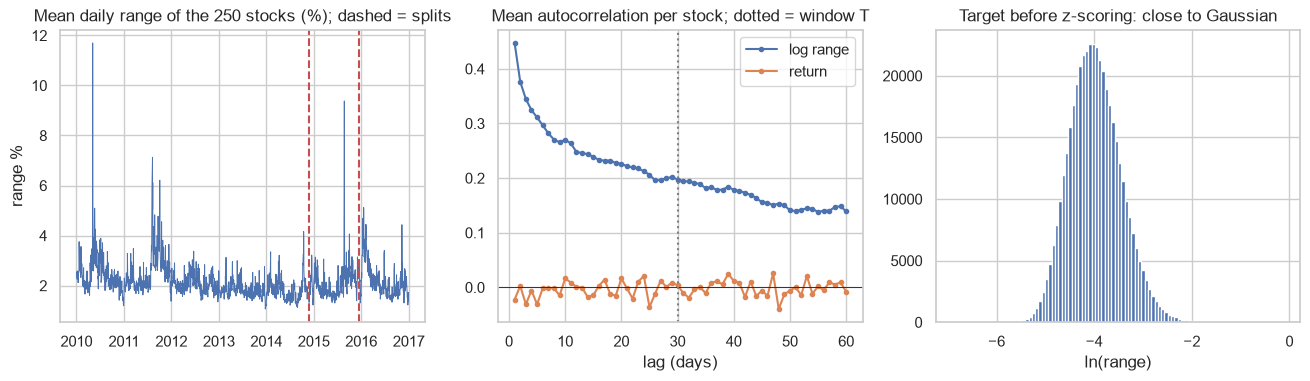

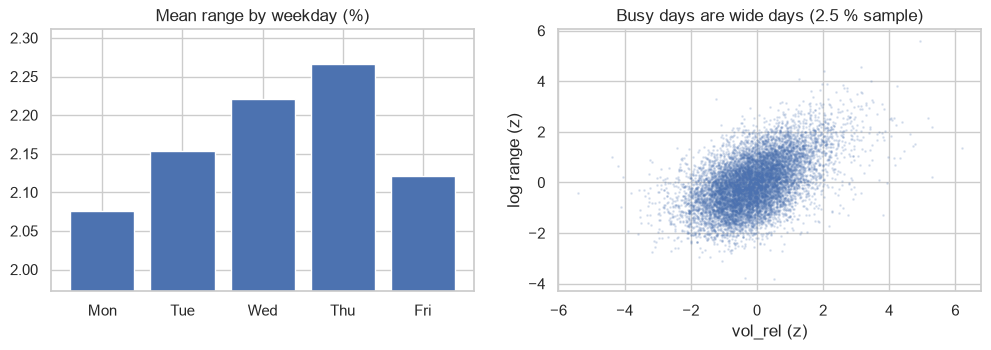

log-range autocorrelation: lag 1 0.45, lag 5 0.31, lag 22 0.22, lag 60 0.14 | return lag 1 -0.022


In [5]:
mkt_rng = np.exp(S[..., 0] * sd_t + mu_t).mean(0) * 100                 # mean range of the 250 stocks per day
fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
ax[0].plot(days, mkt_rng, lw=0.7); ax[0].axvline(days[c1], c="C3", ls="--"); ax[0].axvline(days[c2], c="C3", ls="--")
ax[0].set(title="Mean daily range of the 250 stocks (%); dashed = splits", ylabel="range %")
lr = S[..., 0]; rr = S[..., 1]
acf = lambda A, k: np.mean([np.corrcoef(a[:-k], a[k:])[0, 1] for a in A])
lags = range(1, 61)
ax[1].plot(lags, [acf(lr, k) for k in lags], marker=".", label="log range"); ax[1].plot(lags, [acf(rr, k) for k in lags], marker=".", label="return")
ax[1].axhline(0, c="k", lw=.6); ax[1].axvline(T, c="grey", ls=":"); ax[1].set(xlabel="lag (days)", title="Mean autocorrelation per stock; dotted = window T"); ax[1].legend()
ax[2].hist(S[..., 0].ravel() * sd_t + mu_t, bins=100); ax[2].set(xlabel="ln(range)", title="Target before z-scoring: close to Gaussian")
fig.savefig(IMG / f"{CODE}_eda_risk.png"); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
dow = pd.Series(mkt_rng, index=days).groupby(days.dayofweek).mean()
ax[0].bar(["Mon", "Tue", "Wed", "Thu", "Fri"], dow.values); ax[0].set(ylim=(dow.min() * .95, dow.max() * 1.02), title="Mean range by weekday (%)")
ax[1].scatter(S[..., 4].ravel()[::40], S[..., 0].ravel()[::40], s=1, alpha=.15); ax[1].set(xlabel="vol_rel (z)", ylabel="log range (z)", title="Busy days are wide days (2.5 % sample)")
fig.savefig(IMG / f"{CODE}_eda_volume.png"); plt.show()
print(f"log-range autocorrelation: lag 1 {acf(lr, 1):.2f}, lag 5 {acf(lr, 5):.2f}, lag 22 {acf(lr, 22):.2f}, lag 60 {acf(lr, 60):.2f} | return lag 1 {acf(rr, 1):.3f}")

**Reading.** The log range is strongly autocorrelated and the correlation fades slowly (still clearly positive after a month), while returns have almost none. That is the structure an RNN can exploit: its state must summarise "how nervous has this stock been recently", a slowly moving quantity — much like the HAR baseline's day/week/month averages. The test period contains a volatile start (Jan–Feb 2016 sell-off) and a calm end.

## 4. RNN from scratch (NumPy) — run `ST-SC-RNN`

**Forward.** $h_t=\tanh(x_tW_{xh}+h_{t-1}W_{hh}+b)$ for $t=1..30$, $h_0=0$; $\hat y=h_{30}W_{hy}+b_y$. A good state behaves like an exponentially weighted average of past ranges: $h_t\approx a\,h_{t-1}+(1-a)\,x_t$ is exactly what one recurrent unit with $W_{hh}=a$ computes in its linear regime ($\tanh z\approx z$ for small $z$). With $a=0.9$, a shock 10 days ago keeps $0.9^{10}=35\,\%$ of its weight, 30 days ago $4\,\%$.

**Backward (BPTT)** — same equations as in the concepts notebook, now over 30 steps:

$$\delta_{30}=\tfrac2N(\hat y-y)W_{hy}^\top,\qquad \delta_{t-1}=\big(\delta_t\odot(1-h_t^2)\big)W_{hh}^\top,\qquad \frac{\partial L}{\partial W_{xh}}=\sum_{t=1}^{30}x_t^\top\big(\delta_t\odot(1-h_t^2)\big).$$

Thirty steps means 29 multiplications by $\mathrm{diag}(1-h^2)W_{hh}^\top$ between the target and day 1 — three times as many as for the 10-order EC windows, so vanishing gradients matter more here.

**Shapes.** $(128,30,7)$ → `X @ Wxh` $(128,30,32)$ → 30 steps on $(128,32)$ → $(128,)$. Parameters $224+1024+32+32+1=$ **1,313**.

In [6]:
class ScratchRNN:
    """Single-layer vanilla RNN, many-to-one: h_t = tanh(x_t Wxh + h_{t-1} Whh + b), yhat = h_T Why + by. NumPy only."""
    def __init__(self, F, H, seed=SEED, dtype=np.float32):
        rng = np.random.default_rng(seed)
        lim = np.sqrt(6 / (F + H))                                   # Glorot uniform (Keras kernel default)
        q, r = np.linalg.qr(rng.standard_normal((H, H)))             # orthogonal recurrent matrix (Keras default)
        lh = np.sqrt(6 / (H + 1))
        self.p = {"Wxh": rng.uniform(-lim, lim, (F, H)), "Whh": q * np.sign(np.diag(r)), "bh": np.zeros(H),
                  "Why": rng.uniform(-lh, lh, (H, 1)), "by": np.zeros(1)}
        self.p = {k: v.astype(dtype) for k, v in self.p.items()}

    def n_params(self): return int(sum(v.size for v in self.p.values()))

    def forward(self, X):
        p = self.p; N, Tn, _ = X.shape
        xw = X @ p["Wxh"]                                            # input part of every step at once: (N, T, H)
        h = np.zeros((N, p["Whh"].shape[0]), X.dtype); hs = [h]
        for t in range(Tn):                                          # the recurrence itself cannot be vectorised over t
            h = np.tanh(xw[:, t] + h @ p["Whh"] + p["bh"]); hs.append(h)
        return (h @ p["Why"] + p["by"])[:, 0], hs

    def loss_grads(self, X, y):
        """MSE and its gradients by back-propagation through time; also ||dL/dh_t|| for t = 1..T."""
        p = self.p; yhat, hs = self.forward(X); N, Tn, _ = X.shape
        err = yhat - y; loss = float(np.mean(err ** 2))
        dy = (2.0 / N) * err[:, None]                                # dL/dyhat, (N, 1)
        g = {k: np.zeros_like(v) for k, v in p.items()}
        g["Why"] = hs[-1].T @ dy; g["by"] = dy.sum(0)
        dh = dy @ p["Why"].T                                         # dL/dh_T, (N, H)
        norms = np.zeros(Tn)
        for t in range(Tn, 0, -1):
            norms[t - 1] = np.linalg.norm(dh)
            dz = dh * (1.0 - hs[t] ** 2)                             # back through tanh
            g["Wxh"] += X[:, t - 1].T @ dz                           # shared weights: add every step's share
            g["Whh"] += hs[t - 1].T @ dz
            g["bh"] += dz.sum(0)
            dh = dz @ p["Whh"].T                                     # hand the signal to step t-1
        return loss, g, norms

    def predict(self, X, bs=4096):
        return np.concatenate([self.forward(X[i:i + bs])[0] for i in range(0, len(X), bs)])


class Adam:
    """m <- b1 m + (1-b1) g ; v <- b2 v + (1-b2) g^2 ; theta <- theta - lr * m_hat / (sqrt(v_hat) + eps)."""
    def __init__(self, params, lr=LR, b1=0.9, b2=0.999, eps=EPS):
        self.lr, self.b1, self.b2, self.eps, self.t = lr, b1, b2, eps, 0
        self.m = {k: np.zeros_like(v) for k, v in params.items()}; self.v = {k: np.zeros_like(v) for k, v in params.items()}
    def step(self, params, grads):
        self.t += 1
        for k in params:
            self.m[k] = self.b1 * self.m[k] + (1 - self.b1) * grads[k]
            self.v[k] = self.b2 * self.v[k] + (1 - self.b2) * grads[k] ** 2
            mh = self.m[k] / (1 - self.b1 ** self.t); vh = self.v[k] / (1 - self.b2 ** self.t)
            params[k] -= self.lr * mh / (np.sqrt(vh) + self.eps)


def clip_global_norm(grads, max_norm=CLIP):
    total = np.sqrt(sum(float((g.astype(np.float64) ** 2).sum()) for g in grads.values()))
    scale = min(1.0, max_norm / (total + 1e-6))
    for k in grads: grads[k] *= scale
    return total


def fit_scratch(model, Xtr, ytr, Xva, yva):
    opt = Adam(model.p); rng = np.random.default_rng(SEED)
    hist = {"loss": [], "val_loss": []}; times = []; best, wait, best_p = np.inf, 0, None
    t_all = time.perf_counter()
    for ep in range(MAX_EPOCHS):
        t0 = time.perf_counter(); perm = rng.permutation(len(Xtr)); tot = 0.0
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            loss, g, _ = model.loss_grads(Xtr[idx], ytr[idx])
            clip_global_norm(g); opt.step(model.p, g); tot += loss * len(idx)
        val = float(np.mean((model.predict(Xva) - yva) ** 2))
        hist["loss"].append(tot / len(perm)); hist["val_loss"].append(val); times.append(time.perf_counter() - t0)
        if val < best - 1e-12: best, wait, best_p = val, 0, {k: v.copy() for k, v in model.p.items()}
        else: wait += 1
        if wait >= PATIENCE: break
    model.p = best_p                                                 # restore the best epoch
    return hist, times, time.perf_counter() - t_all

### Gradient check

Analytic BPTT gradients vs central differences ($\epsilon=10^{-6}$, float64) for all 1,313 parameters on 8 real 30-day windows; pass if $\max|a-n|/\max|a|<10^{-5}$ for every matrix.

In [7]:
def gradient_check(F, n=8, eps=1e-6, seed=0):
    """Analytic BPTT gradients vs central finite differences, float64, on n real windows."""
    m = ScratchRNN(F, H, seed=seed, dtype=np.float64)
    for k in ("bh", "by"): m.p[k] = np.random.default_rng(1).normal(0, 0.1, m.p[k].shape)      # non-zero biases
    X, y = Xtr[:n].astype(np.float64), ytr[:n].astype(np.float64)
    _, g, _ = m.loss_grads(X, y); rows = []
    for k, v in m.p.items():
        num = np.zeros_like(v)
        for ix in np.ndindex(*v.shape):
            old = v[ix]; v[ix] = old + eps; lp = m.loss_grads(X, y)[0]; v[ix] = old - eps; lm = m.loss_grads(X, y)[0]; v[ix] = old
            num[ix] = (lp - lm) / (2 * eps)
        rows.append((k, v.shape, float(np.abs(g[k] - num).max() / max(np.abs(g[k]).max(), 1e-12))))
    return pd.DataFrame(rows, columns=["parameter", "shape", "max error / max |gradient|"])

gc = gradient_check(Xtr.shape[2]); display(gc)
assert gc["max error / max |gradient|"].max() < 1e-5, "BPTT gradients disagree with finite differences"

,parameter,shape,max error / max |gradient|
0,Wxh,"(7, 32)",4.291966e-10
1,Whh,"(32, 32)",6.421527e-10
2,bh,"(32,)",4.471137e-10
3,Why,"(32, 1)",1.081305e-10
4,by,"(1,)",4.439455e-12


### Training

The scratch net starts from `W0`, which is also copied into Keras and PyTorch. One epoch ≈ 303k windows / 128 ≈ 2,370 updates of 30-step BPTT, so an epoch costs about 3× an EC epoch.

scratch parameters: 1313  = F*H + H*H + H + H + 1 = 1313


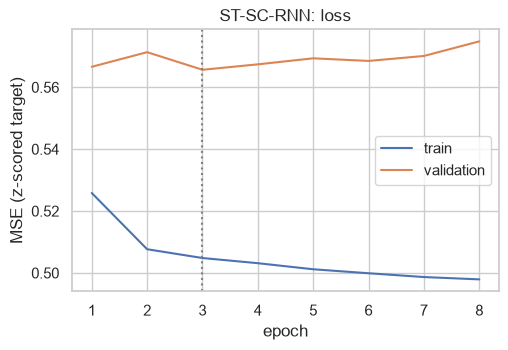

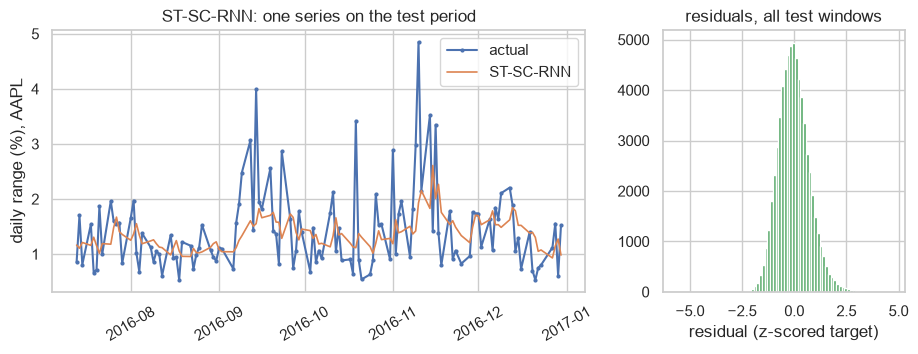

ST-SC-RNN: params 1,313 | epochs 8 (best 3) | 2.3s/epoch | total 18s | test rmse_pct 1.1897, mae_pct 0.6893, rmse 0.7472, r2_oos 0.5216, dir_acc 0.7048


In [8]:
F_ = Xtr.shape[2]
W0 = {k: v.copy() for k, v in ScratchRNN(F_, H).p.items()}          # starting weights shared by all three core runs
sc = ScratchRNN(F_, H)
print("scratch parameters:", sc.n_params(), " = F*H + H*H + H + H + 1 =", F_ * H + H * H + H + H + 1)
hist, times, total = fit_scratch(sc, Xtr, ytr, Xva, yva)
finalize(f"{CODE}-SC-RNN", "Scratch", "RNN", hist, sc.n_params(), times, total, sc.predict);

### How far back does the signal reach?

Gradient norm at each of the 30 days relative to the last day. If day 1 receives $<1\,\%$, the RNN effectively uses the last one to two weeks — and the monthly component of volatility must then come from the slowly varying hidden state, not from learning on old inputs.

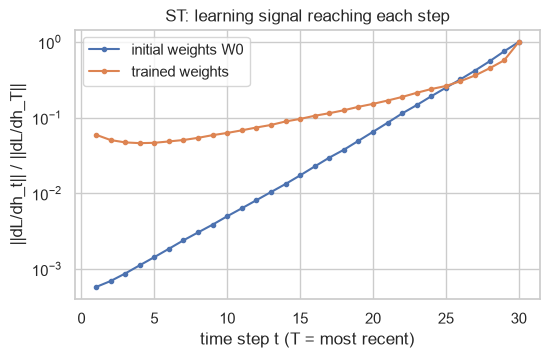

oldest step receives 0.059 of the newest step's gradient (trained), 0.001 (initial)


In [9]:
idx = np.random.default_rng(0).choice(len(Xte), 512, replace=False)
trained = sc.p; norms_trained = sc.loss_grads(Xte[idx], yte[idx])[2]
sc.p = {k: v.copy() for k, v in W0.items()}; norms_init = sc.loss_grads(Xte[idx], yte[idx])[2]; sc.p = trained
fig, ax = plt.subplots(figsize=(6, 3.5))
for n_, l_ in ((norms_init, "initial weights W0"), (norms_trained, "trained weights")):
    ax.semilogy(range(1, T + 1), n_ / n_[-1], marker="o", ms=3, label=l_)
ax.set(xlabel="time step t (T = most recent)", ylabel="||dL/dh_t|| / ||dL/dh_T||", title=f"{CODE}: learning signal reaching each step"); ax.legend()
fig.savefig(IMG / f"{CODE}-SC-RNN_gradnorm.png"); plt.show()
print(f"oldest step receives {norms_trained[0] / norms_trained[-1]:.3f} of the newest step's gradient (trained), "
      f"{norms_init[0] / norms_init[-1]:.3f} (initial)")

## 5. RNN in Keras — runs `ST-TF-RNN`, `ST-TF-LSTM`, `ST-TF-GRU`

`SimpleRNN(32)` + `Dense(1)`, compiled with Adam(1e-3, `global_clipnorm=1.0`) and MSE; `EarlyStopping(patience=5, restore_best_weights=True)`. Copying `W0`: `kernel` (7,32) = $W_{xh}$, `recurrent_kernel` (32,32) = $W_{hh}$, `bias` (32) = $b$; Dense `kernel` (32,1), `bias` (1). Keras' parameter count must print 1,313.

In [10]:
def build_keras(kind, F, Tn, copy_init=None):
    cell = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    m = keras.Sequential([layers.Input((Tn, F)), cell(H), layers.Dense(1)])
    m.compile(optimizer=keras.optimizers.Adam(LR, epsilon=EPS, global_clipnorm=CLIP), loss="mse")
    if copy_init is not None:                                        # SimpleRNN weights: [kernel (F,H), recurrent_kernel (H,H), bias (H)]
        m.layers[0].set_weights([copy_init["Wxh"], copy_init["Whh"], copy_init["bh"]])
        m.layers[1].set_weights([copy_init["Why"], copy_init["by"]])
    return m

class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self.t0 = time.perf_counter()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.perf_counter() - self.t0)

def run_keras(kind, copy_init=None):
    run_id = f"{CODE}-TF-{kind}"; keras.utils.set_random_seed(SEED)
    m = build_keras(kind, Xtr.shape[2], Xtr.shape[1], copy_init)
    timer = EpochTimer(); es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
    t0 = time.perf_counter()
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), batch_size=BATCH, epochs=MAX_EPOCHS, shuffle=True, callbacks=[es, timer], verbose=0)
    total = time.perf_counter() - t0
    pred = lambda X: m.predict(X, batch_size=4096, verbose=0)[:, 0]
    return finalize(run_id, "Keras", kind, h.history, m.count_params(), timer.times, total, pred)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

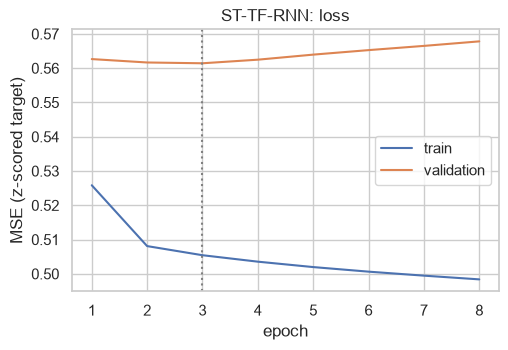

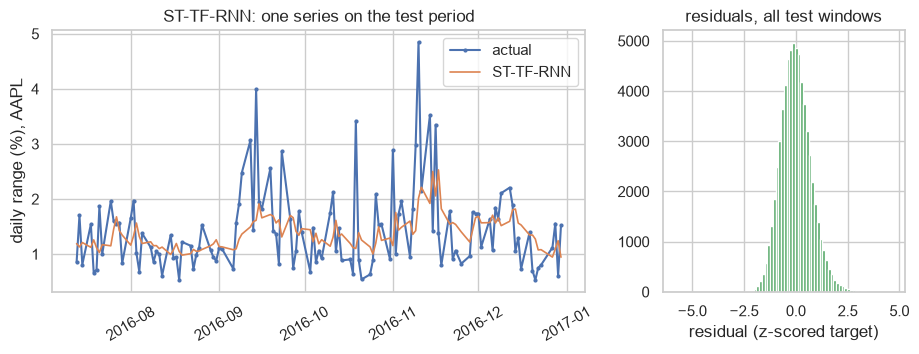

ST-TF-RNN: params 1,313 | epochs 8 (best 3) | 5.5s/epoch | total 45s | test rmse_pct 1.1894, mae_pct 0.6821, rmse 0.7413, r2_oos 0.5291, dir_acc 0.7077


In [11]:
build_keras("RNN", Xtr.shape[2], T, W0).summary()
run_keras("RNN", copy_init=W0);

**LSTM and GRU.** Over 30 days the additive cell update of the LSTM, $c_t=f_t\odot c_{t-1}+i_t\odot\tilde c_t$, can hold "the stock has been nervous for a month" with $f_t\approx1$ — exactly the long component that a vanilla RNN struggles to keep. Keras initialises the forget bias to 1, so at the start $f\approx\sigma(1)=0.73$ and the memory survives 30 days with $0.73^{30}\approx10^{-4}$ — learning must push $f$ higher.

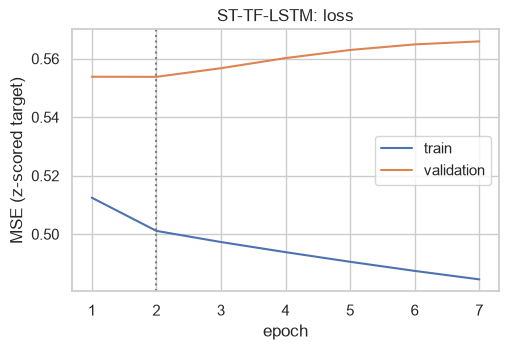

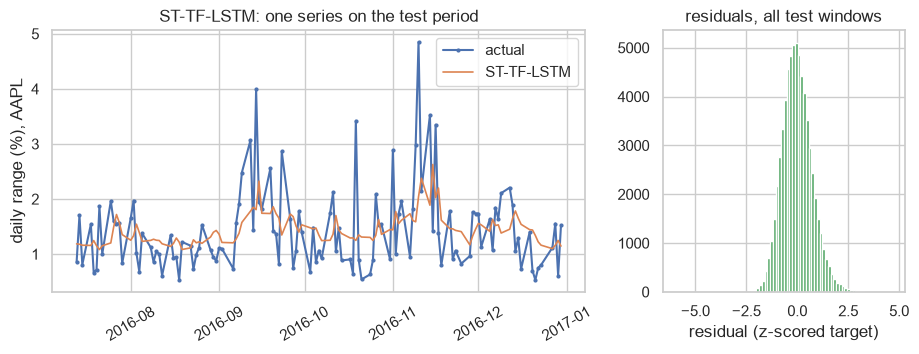

ST-TF-LSTM: params 5,153 | epochs 7 (best 2) | 14.8s/epoch | total 107s | test rmse_pct 1.1559, mae_pct 0.6734, rmse 0.7351, r2_oos 0.5370, dir_acc 0.7107


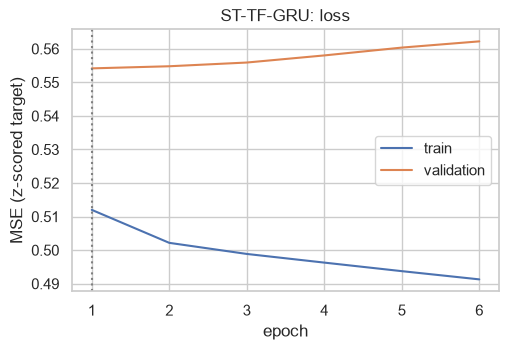

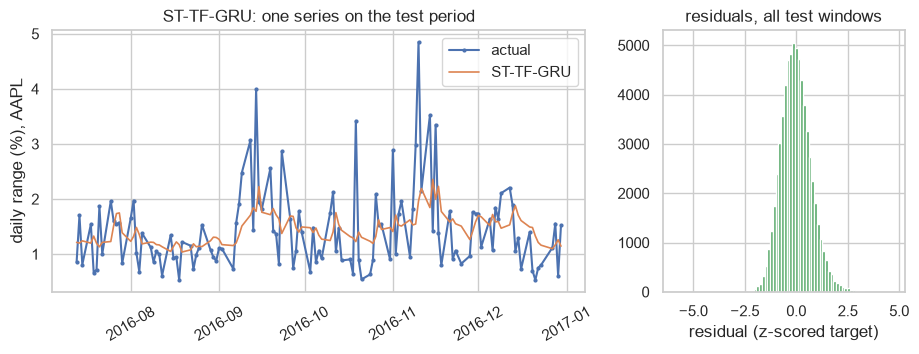

ST-TF-GRU: params 3,969 | epochs 6 (best 1) | 17.3s/epoch | total 104s | test rmse_pct 1.1606, mae_pct 0.6742, rmse 0.7351, r2_oos 0.5370, dir_acc 0.7107


In [12]:
run_keras("LSTM"); run_keras("GRU");

## 6. RNN in PyTorch — runs `ST-PT-RNN`, `ST-PT-LSTM`, `ST-PT-GRU`

`nn.RNN(7, 32, batch_first=True)` + `nn.Linear(32, 1)`, explicit loop with `clip_grad_norm_(…, 1.0)`. Copying `W0` needs a transpose (`weight_ih_l0` = $W_{xh}^\top$, shape $32\times7$) and the second bias `bias_hh_l0` is zeroed and frozen so that the trainable count is 1,313.

In [13]:
class TorchSeq(nn.Module):
    def __init__(self, kind, F, hidden=H):
        super().__init__()
        self.rnn = {"RNN": nn.RNN, "LSTM": nn.LSTM, "GRU": nn.GRU}[kind](F, hidden, batch_first=True)   # nn.RNN: tanh by default
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        out, _ = self.rnn(x)                                         # out: (N, T, H), every h_t
        return self.head(out[:, -1]).squeeze(-1)                     # many-to-one: only h_T is used

def build_torch(kind, F, copy_init=None):
    torch.manual_seed(SEED); m = TorchSeq(kind, F)
    if copy_init is not None:                                        # PyTorch stores W_ih (H,F) and W_hh (H,H): transposes of ours
        with torch.no_grad():
            m.rnn.weight_ih_l0.copy_(torch.from_numpy(copy_init["Wxh"].T)); m.rnn.weight_hh_l0.copy_(torch.from_numpy(copy_init["Whh"].T))
            m.rnn.bias_ih_l0.copy_(torch.from_numpy(copy_init["bh"])); m.rnn.bias_hh_l0.zero_()
            m.head.weight.copy_(torch.from_numpy(copy_init["Why"].T)); m.head.bias.copy_(torch.from_numpy(copy_init["by"]))
        m.rnn.bias_hh_l0.requires_grad_(False)                       # second bias frozen at 0 -> same parameters as Keras / scratch
    return m.to(dev)

def n_trainable(m): return sum(p.numel() for p in m.parameters() if p.requires_grad)

def predict_torch(m, X, bs=4096):
    m.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs): out.append(m(torch.from_numpy(X[i:i + bs]).to(dev)).cpu().numpy())
    return np.concatenate(out)

def fit_torch(m):
    params = [p for p in m.parameters() if p.requires_grad]
    opt = torch.optim.Adam(params, lr=LR, eps=EPS)
    Xt, yt = torch.from_numpy(Xtr).to(dev), torch.from_numpy(ytr).to(dev)
    Xv, yv = torch.from_numpy(Xva).to(dev), torch.from_numpy(yva).to(dev)
    gen = torch.Generator().manual_seed(SEED)
    hist = {"loss": [], "val_loss": []}; times = []; best, wait, best_state = np.inf, 0, None
    t_all = time.perf_counter()
    for ep in range(MAX_EPOCHS):
        t0 = time.perf_counter(); m.train(); perm = torch.randperm(len(Xt), generator=gen).to(dev); tot = torch.zeros((), device=dev)
        for i in range(0, len(perm), BATCH):
            idx = perm[i:i + BATCH]
            opt.zero_grad(set_to_none=True)
            loss = Fn.mse_loss(m(Xt[idx]), yt[idx]); loss.backward()          # autograd does the BPTT of the scratch section
            torch.nn.utils.clip_grad_norm_(params, CLIP); opt.step()
            tot += loss.detach() * len(idx)
        m.eval()
        with torch.no_grad():
            val = sum(((m(Xv[i:i + 4096]) - yv[i:i + 4096]) ** 2).sum().item() for i in range(0, len(Xv), 4096)) / len(Xv)
        hist["loss"].append(tot.item() / len(perm)); hist["val_loss"].append(val); times.append(time.perf_counter() - t0)
        if val < best - 1e-12: best, wait, best_state = val, 0, {k: v.detach().clone() for k, v in m.state_dict().items()}
        else: wait += 1
        if wait >= PATIENCE: break
    m.load_state_dict(best_state)
    return hist, times, time.perf_counter() - t_all

def run_torch(kind, copy_init=None):
    run_id = f"{CODE}-PT-{kind}"
    m = build_torch(kind, Xtr.shape[2], copy_init)
    hist, times, total = fit_torch(m)
    return finalize(run_id, "PyTorch", kind, hist, n_trainable(m), times, total, lambda X: predict_torch(m, X))

### Same weights, same output

Three implementations, one function: with `W0` loaded, 64 validation windows must give the same predictions to $<10^{-5}$ and the parameter counts must be equal.

In [14]:
xs = Xva[:64]
y_sc = ScratchRNN(F_, H).forward(xs)[0]
y_k = build_keras("RNN", F_, T, W0).predict(xs, verbose=0)[:, 0]
pm = build_torch("RNN", F_, W0); y_p = predict_torch(pm, xs)
print(f"max |scratch - Keras|   = {np.abs(y_sc - y_k).max():.2e}\nmax |scratch - PyTorch| = {np.abs(y_sc - y_p).max():.2e}\nmax |Keras - PyTorch|   = {np.abs(y_k - y_p).max():.2e}")
assert max(np.abs(y_sc - y_k).max(), np.abs(y_sc - y_p).max()) < 1e-5
n_k = build_keras("RNN", F_, T, W0).count_params(); n_p = n_trainable(pm); n_s = ScratchRNN(F_, H).n_params()
print("parameters  scratch / Keras / PyTorch:", n_s, n_k, n_p); assert n_s == n_k == n_p
pc = pd.DataFrame({k: {"Keras": build_keras(k, F_, T).count_params(), "PyTorch (all params)": sum(p.numel() for p in build_torch(k, F_).parameters())}
                   for k in ("RNN", "GRU", "LSTM")}).T
display(pc)

max |scratch - Keras|   = 3.58e-07
max |scratch - PyTorch| = 2.38e-07
max |Keras - PyTorch|   = 3.28e-07
parameters  scratch / Keras / PyTorch: 1313 1313 1313


,Keras,PyTorch (all params)
RNN,1313,1345
GRU,3969,3969
LSTM,5153,5281


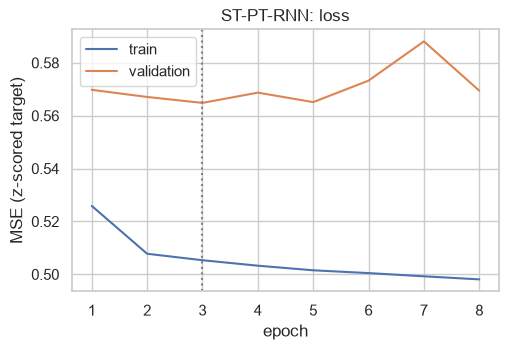

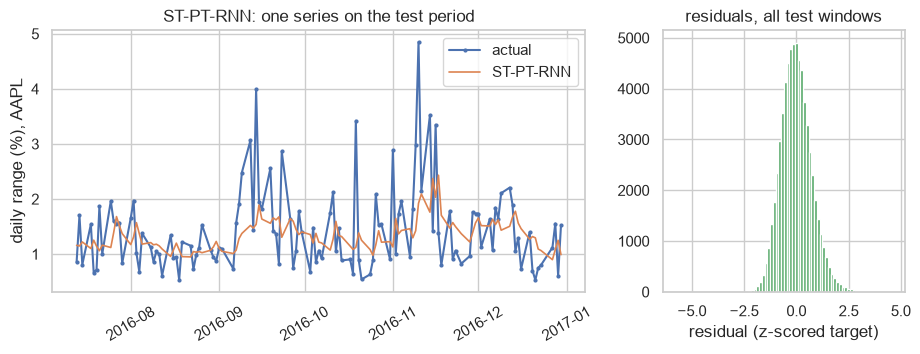

ST-PT-RNN: params 1,313 | epochs 8 (best 3) | 8.0s/epoch | total 64s | test rmse_pct 1.1842, mae_pct 0.6828, rmse 0.7418, r2_oos 0.5285, dir_acc 0.7075


In [15]:
run_torch("RNN", copy_init=W0);

**LSTM and GRU in PyTorch** (default uniform init, forget bias **not** set to 1 — one of the few real differences from Keras, so Keras and PyTorch LSTMs may end at different points).

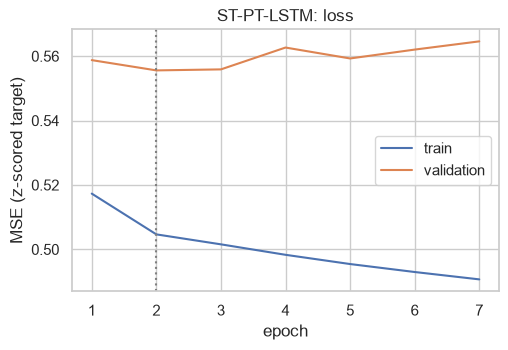

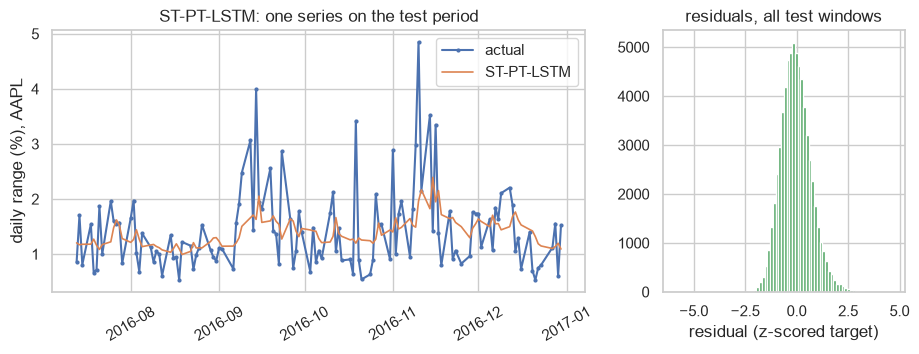

ST-PT-LSTM: params 5,281 | epochs 7 (best 2) | 22.1s/epoch | total 155s | test rmse_pct 1.1454, mae_pct 0.6765, rmse 0.7374, r2_oos 0.5341, dir_acc 0.7096


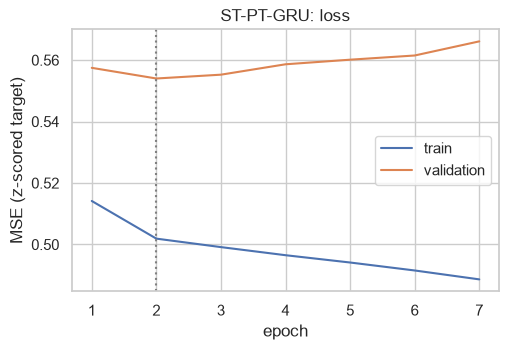

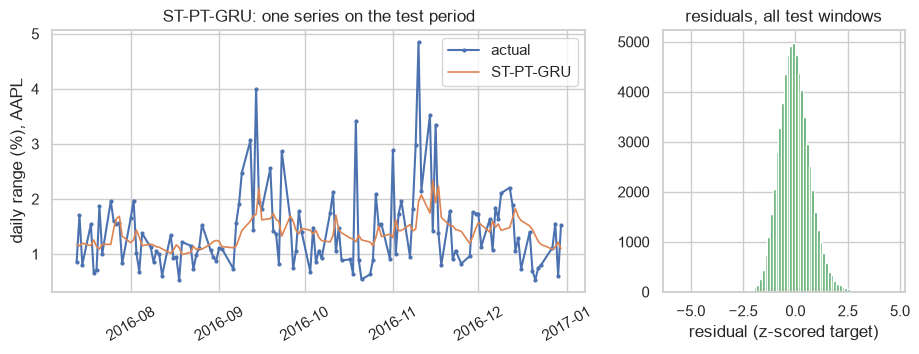

ST-PT-GRU: params 3,969 | epochs 7 (best 2) | 17.9s/epoch | total 126s | test rmse_pct 1.1486, mae_pct 0.6765, rmse 0.7381, r2_oos 0.5332, dir_acc 0.7077


In [16]:
run_torch("LSTM"); run_torch("GRU");

## 7. Comparison

Test period = last 15 % of trading days, all 250 stocks. Questions: (a) does any RNN beat **HAR**, the standard linear volatility model? (b) do scratch, Keras and PyTorch agree? (c) do gates help over 30 days of memory? (d) cost per epoch.

In [17]:
rows = []
for name, p in BASELINES.items():
    rows.append(dict(run_id=f"baseline: {name}", impl="-", **metrics_fn(yte, p)))
for rid, r in RUNS.items():
    rows.append(dict(run_id=rid, impl=r["impl"], params=r["params"], epochs=r["epochs_run"], best_epoch=r["best_epoch"],
                     s_per_epoch=round(r["time_per_epoch_s"], 2), total_s=round(r["total_time_s"]), infer_ms_per_1k=round(r["infer_ms_per_1k"], 2), **r["test"]))
table = pd.DataFrame(rows).set_index("run_id")
table.to_csv(RES / f"{CODE}_comparison.csv")
display(table.style.format(precision=4, na_rep="").background_gradient(subset=[KEY_METRIC], cmap="Greens_r"))

,impl,rmse_pct,mae_pct,rmse,r2_oos,dir_acc,params,epochs,best_epoch,s_per_epoch,total_s,infer_ms_per_1k
run_id,,,,,,,,,,,,
baseline: persistence (today),-,1.3852,0.8639,0.9193,0.2759,,,,,,,
baseline: 5-day mean,-,1.1631,0.7172,0.7861,0.4705,0.6833,,,,,,
baseline: 22-day mean,-,1.1888,0.7265,0.7948,0.4587,0.6943,,,,,,
baseline: train mean,-,1.6528,0.9865,1.0804,0.0000,0.6424,,,,,,
baseline: HAR linear (day+week+month),-,1.1449,0.6820,0.7485,0.5200,0.7004,,,,,,
ST-SC-RNN,Scratch,1.1897,0.6893,0.7472,0.5216,0.7048,1313.0000,8.0000,3.0000,2.3100,18.0000,2.7200
ST-TF-RNN,Keras,1.1894,0.6821,0.7413,0.5291,0.7077,1313.0000,8.0000,3.0000,5.4500,45.0000,6.1900
ST-TF-LSTM,Keras,1.1559,0.6734,0.7351,0.5370,0.7107,5153.0000,7.0000,2.0000,14.8500,107.0000,13.3200
ST-TF-GRU,Keras,1.1606,0.6742,0.7351,0.5370,0.7107,3969.0000,6.0000,1.0000,17.2900,104.0000,14.8900


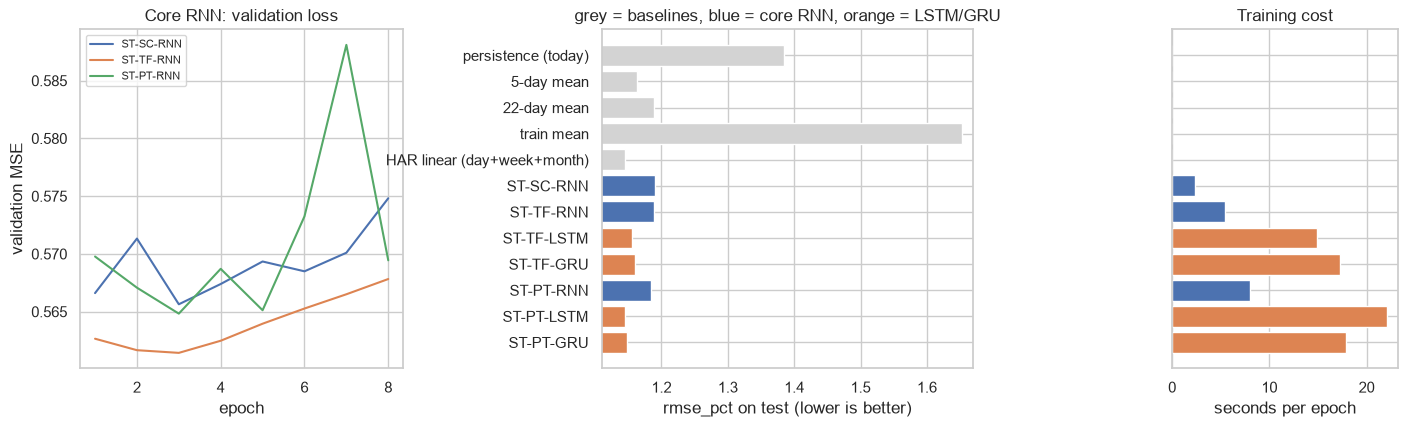

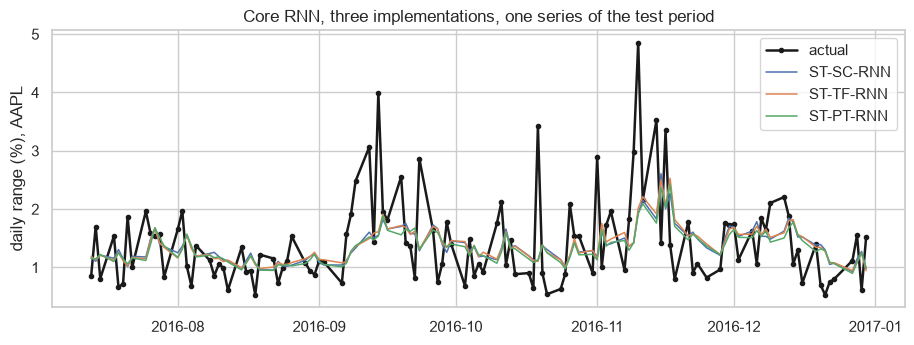

mean |difference| between implementations' test predictions (z units): {'SC-TF': 0.078, 'SC-PT': 0.0748, 'TF-PT': 0.0488}


In [18]:
core = [f"{CODE}-SC-RNN", f"{CODE}-TF-RNN", f"{CODE}-PT-RNN"]
fig = plt.figure(figsize=(17, 4.4)); gs = fig.add_gridspec(1, 3, wspace=0.65, width_ratios=[1, 1.15, 0.7])
a0 = fig.add_subplot(gs[0]); a1 = fig.add_subplot(gs[1]); a2 = fig.add_subplot(gs[2], sharey=a1)
for rid in core:
    h = RUNS[rid]["history"]; a0.plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], label=rid)
a0.set(xlabel="epoch", ylabel="validation MSE", title="Core RNN: validation loss"); a0.legend(fontsize=8)
labels = list(BASELINES) + list(RUNS)
vals = [metrics_fn(yte, p)[KEY_METRIC] for p in BASELINES.values()] + [RUNS[r]["test"][KEY_METRIC] for r in RUNS]
colors = ["lightgrey"] * len(BASELINES) + ["C0" if r in core else "C1" for r in RUNS]
a1.barh(labels, vals, color=colors); a1.invert_yaxis(); a1.set_xlim(min(vals) * 0.97, max(vals) * 1.01)
a1.set(xlabel=f"{KEY_METRIC} on test (lower is better)", title="grey = baselines, blue = core RNN, orange = LSTM/GRU")
a2.barh(labels, [0] * len(BASELINES) + [RUNS[r]["time_per_epoch_s"] for r in RUNS], color=colors)
a2.set(xlabel="seconds per epoch", title="Training cost"); plt.setp(a2.get_yticklabels(), visible=False)
fig.savefig(IMG / f"{CODE}_compare.png"); plt.show()

fig, ax = plt.subplots(figsize=(11, 3.6))
xs, actual, _, xlabel, ylabel = overlay_slice(RUNS[core[0]]["pred"])
ax.plot(xs, actual, c="k", lw=1.8, marker=".", label="actual")
for rid in core: ax.plot(xs, overlay_slice(RUNS[rid]["pred"])[2], lw=1.1, label=rid)
ax.set(xlabel=xlabel, ylabel=ylabel, title="Core RNN, three implementations, one series of the test period"); ax.legend()
fig.savefig(IMG / f"{CODE}_overlay.png"); plt.show()

P = np.stack([RUNS[r]["pred"] for r in core])
print("mean |difference| between implementations' test predictions (z units):",
      {f"{a[3:5]}-{b[3:5]}": round(float(np.abs(P[i] - P[j]).mean()), 4) for i, a in enumerate(core) for j, b in enumerate(core) if i < j})

## 8. Conclusion

1. **Tomorrow's risk is predictable; all models beat the naive forecasts by far.** Persistence has RMSE 1.39 percentage points of range ($R^2=0.28$), the 5-day mean 1.16 ($R^2=0.47$). The RNNs reach $R^2=0.52$–$0.54$ and directional accuracy 70.5–71.1 % (will tomorrow be calmer or wilder than today?) — volatility clustering is real and learnable, unlike returns (lag-1 autocorrelation of returns −0.02 vs 0.45 for the log range).
2. **But the classic HAR model is almost as good.** HAR (3 coefficients) has $R^2=0.520$, RMSE 1.145 pp, direction 70.0 %. The vanilla RNNs beat it on the z-scale they were trained for ($R^2$ 0.522–0.529) and lose slightly in percentage points (1.18–1.19); no model beats HAR in percentage points — the best, PyTorch LSTM, ties it (1.1454 vs 1.1449 pp) with a higher $R^2$ (0.534). The RNN essentially rediscovers "weighted average of recent volatility".
3. **Scratch, Keras and PyTorch agree.** Same weights → forward difference < 4e-7, 1,313 parameters each; trained: RMSE 0.747 / 0.741 / 0.742 (z), all stopping at the same epoch (best 3). The scratch run is 0.8 % worse — different shuffling, not different maths.
4. **Gates help over 30 days.** LSTM/GRU improve $R^2$ by about 0.01 over the vanilla RNN and close the pp-RMSE gap to HAR (1.145–1.161 vs 1.18–1.19). For the vanilla RNN the oldest of the 30 days receives only 6 % of the newest day's gradient (0.1 % at initialisation): the vanishing gradient from the concepts notebook, measured on real data.
5. **Cost and caveat.** Per epoch on CPU: scratch 2.3 s, Keras 5.5 s, PyTorch 8.0 s; LSTM/GRU 15–22 s. Training stops after 1–3 useful epochs — the signal is simple and the noise is large. One seed, one split, a test year that contains the early-2016 sell-off: differences below ~1 % are not a ranking.